## <b><u>Infrared.city-1</u>: Tree detection</b>
### <b>Introduction</b>

As urban areas are expanding and global temperatures rise due to climate change, being able to understand how trees can help cool cities has become increasingly important. Furthermore, trees reduce the risk of flooding in cities and promote health and wellbeing. Our project aims at taking the first step in the direction of better tree coverage in urban areas by creating a model which is able to predict tree locations using satellite imagery of densely populated areas. <i>In this notebook we will fetch and prepear the data:</i>

### <b>Notebook structure 1</b>

&nbsp;&nbsp;&nbsp;<b>1. Fetching tree catastratee data</b><br>
&nbsp;&nbsp;&nbsp;<b>2. Cleaning tree catastratee data</b><br>
&nbsp;&nbsp;&nbsp;<b>3. Saving cleaned tree catastratee data</b><br>

### <b>Shared folder structure</b>
/home/jovyan/ideas-dslab-group1-shared/<br>
├── <b>raw data/</b> (backup)<br>
│&ensp;&ensp;&ensp;      ├── baumkataster data/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── vienna_baumkataster<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── paris_baumkataster/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── prag_baumkataster/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   └── hamburger_baumkataster/<br>
│&ensp;&ensp;&ensp;   ├── <s>sentinel data/</s> -> already cleaned<br>
│&ensp;&ensp;&ensp;   └── osm data/<br>
└── <b>cleaned data/</b><br>
&ensp;&ensp;&ensp; &ensp;├── baumkataster data/<br>
&ensp;&ensp;&ensp;&ensp;          ├── sentinel data/<br>
&ensp;&ensp;&ensp;&ensp;   └── osm data/<br>
<br>

##  <b>1. Fetching tree catastratee data</b>

For our project we have following <a href="https://opentrees.org/#pos=3.7/52.76/0.38">publicly available data</a>:

In this notebook:

1. <b><a href="https://www.data.gv.at/datasets/c91a4635-8b7d-43fe-9b27-d95dec8392a7?locale=en">Vienna Baumkataster</a></b> <i>Official City of Vienna tree cadastre with tree locations (GeoJSON)</i><b>→ continental</b><br>

2. <b><a href="https://opendata.paris.fr/explore/dataset/les-arbres/export/?disjunctive.espece&disjunctive.typeemplacement&disjunctive.arrondissement&disjunctive.genre&disjunctive.libellefrancais&disjunctive.varieteoucultivar&disjunctive.stadedeveloppement&disjunctive.remarquable">Paris Le Arbres</a></b> <i>Official City of Paris tree cadastre with tree locations (GeoJSON)</i><b>→ western / oceanic</b><br>

3. <b><a href="https://opendata-ajuntament.barcelona.cat/data/en/dataset/arbrat-viari">Barcelona</a></b> <i>Official City of Barcelona tree cadastre with tree locations (JSON)</i><b>→ warm / Mediterranean</b><br>

4. <b><a href="https://metaver.de/trefferanzeige?docuuid=C1C61928-C602-4E37-AF31-2D23901E2540">Hamburg Strassenbaumkataster</a></b> <i>Official City of Hambuger tree cadastre with tree locations (GeoJSON)</i><b>→ northern / maritime</b><br>

In another notebook:

5. <b><a href="https://code.earthengine.google.com/">Sentinel-2 Satellite Images</a></b> <i>Multispectral satellite imagery including 10 m resolution bands (GeoTIFF)</i><br>


6. <b><a href="https://download.geofabrik.de/europe">OpenStreetMap Urban Features</a></b> <i>OpenStreetMap vector data, including urban context such as buildings and roads (GeoPackage)</i><br>

#### We have approx. 154gb free space:<br>

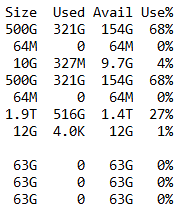<br>

#### And 117gb ram:<br>
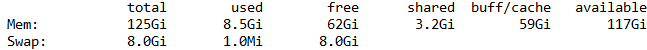:<br>

<b>With that, we can now fetch our datasets accordingly:
## Continental: Vienna Baumkataster

In [1]:
#Lizenz: https://creativecommons.org/licenses/by/4.0/deed.de
#BEZIRK: Wiener Gemeindebezirk, in dem der Baum steht; OBJEKT_STRASSE: Anlage, Objekt oder Straße, in der der Baum steht; BAUMNUMMER: Nummer des Baumes; GEBIETSGRUPPE: Gebiet, in dem der Baum steht; GATTUNG_ART: Information, um welche Baumart es sich handelt; PFLANZJAHR: das Jahr, in dem der Baum gepflanzt wurde; PFLANZJAHR_TXT: Werte aus PFLANZJAHR in Textformat, Nullwerte werden in Text "nicht bekannt" umgewandelt; STAMMUMFANG: Umfang des Baumstammes in cm in einem Meter Höhe; STAMMUMFANG_TXT: Werte aus STAMMUMFANG in Textformat mit Zusatz " cm", Nullwerte werden in Text "nicht bekannt" umgewandelt; BAUMHOEHE: Einteilung in 8 Größenkategorien der Baumhöhe + Nullwert; BAUMHOEHE_TXT: Größenkategorien der Baumhöhe in Textformat direkt aus Quelldatenbank, Leereinträge werden in Text "nicht bekannt" umgewandelt; KRONENDURCHMESSER: Einteilung in 8 Größenkategorien des Baumkronendurchmessers + Nullwert; KRONENDURCHMESSER_TXT: Größenkategorien der Kronendurchmesser in Textformat direkt aus Quelldatenbank, Leereinträge werden in Text "nicht bekannt" umgewandelt;

#already scraped, no needd to rerun it
#uncomment if needed
#import requests

#r = requests.get("https://data.wien.gv.at/daten/geo?service=WFS&version=1.1.0&request=GetFeature&typeName=ogdwien:BAUMKATOGD&outputFormat=json&srsName=EPSG:4326")
#open("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/vienna_baumkataster.geojson", "wb").write(r.content)

In [2]:
!pip install geopandas

In [3]:
import geopandas as gpd

vienna = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/vienna_baumkataster.geojson")
print(vienna.head())
print(len(vienna))

                     id   OBJECTID  BAUM_ID DATENFUEHRUNG  BEZIRK  \
0  BAUMKATOGD.782423078  782423078   264209     magistrat    22.0   
1  BAUMKATOGD.782423081  782423081   164490     magistrat     3.0   
2  BAUMKATOGD.782423082  782423082   145853     magistrat    21.0   
3  BAUMKATOGD.782423083  782423083    18049     magistrat    21.0   
4  BAUMKATOGD.782423084  782423084   408653     magistrat     3.0   

         OBJEKT_STRASSE               GEBIETSGRUPPE  \
0  22., Donaupark, MA42          MA 42 - Parkanlage   
1           Paulusplatz  MA 28 - Straße, Grünanlage   
2       Fillenbaumgasse  MA 28 - Straße, Grünanlage   
3        Großfeldstraße  MA 28 - Straße, Grünanlage   
4           Hörnesgasse  MA 28 - Straße, Grünanlage   

                                         GATTUNG_ART  PFLANZJAHR  \
0          Pinus nigra (Schwarzkiefer, Schwarzföhre)           0   
1                   Tilia platyphyllos (Sommerlinde)        1971   
2  Gleditsia triacanthos 'Skyline' (Säulengledits.

## Western/oceanic: Paris Baumkataster


In [4]:
paris = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/paris_baumkataster.geojson")
print(paris.head())
print(len(paris))

   idbase typeemplacement domanialite   arrondissement complementadresse  \
0  128501           Arbre      Jardin  PARIS 15E ARRDT      POURTOUR N°1   
1  133675           Arbre      Jardin  PARIS 15E ARRDT               NaN   
2  207811           Arbre  Alignement   PARIS 7E ARRDT                65   
3  219024           Arbre  Alignement   PARIS 7E ARRDT                47   
4  233043           Arbre  Alignement  PARIS 15E ARRDT            38 bis   

                                          adresse idemplacement  \
0  SQUARE DU CLOS FEUQUIERES / 30 RUE DESNOUETTES     000101028   
1  SQUARE CARLO SARRABEZOLLES / 1 RUE RENE RAVAUD     000101049   
2                                    QUAI D ORSAY     000301036   
3                                 AVENUE DUQUESNE     000903005   
4                                      RUE BALARD     000602018   

  libellefrancais          genre         espece varieteoucultivar  \
0         Tilleul          Tilia      americana               NaN   
1 

## Warm/mediterranean: Barcelona

In [5]:
import pandas as pd

barcelona = pd.read_json("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/barcelona_baumkataster.json")
print(barcelona.head())
print(barcelona.columns)

        codi    x_etrs89     y_etrs89    latitud  longitud tipus_element  \
0  0000377AR  430700.647  4587547.432  41.436508  2.170511  PALMERA ZONA   
1  0000386AR  430035.239  4587693.836  41.437769  2.162530    ARBRE ZONA   
2  0000387AR  430032.831  4587696.005  41.437788  2.162501    ARBRE ZONA   
3  0000388AR  430030.367  4587698.393  41.437810  2.162471    ARBRE ZONA   
4  0000389AR  430581.230  4587409.021  41.435251  2.169097    ARBRE ZONA   

                    espai_verd                     adreca  cat_especie_id  \
0  Central de Nou Barris, Parc  Pl Major de Nou Barris, 0              48   
1  Central de Nou Barris, Parc    C\ Doctor Letamendi, 90             126   
2  Central de Nou Barris, Parc    C\ Doctor Letamendi, 90             126   
3  Central de Nou Barris, Parc    C\ Doctor Letamendi, 90             126   
4  Central de Nou Barris, Parc             C\ Borgonya, 2              99   

       cat_nom_cientific  ... categoria_arbrat data_plantacio tipus_aigua  \
0  

## Northern/maritime: Hamburg Straßenbaumkataster

EPSG:25832 == metric with meters, prefered for our ML-model for calculations<br>
hpa = all trees without Hamburger Hafen (so we need both datasets)<br>
Obtained via manual download:

In [6]:
hamburg_hpa = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/hamburg_baumkataster/de_hh_up_strassenbaumkataster_EPSG_25832.json")
hamburg = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/baumkataster data/hamburg_baumkataster/de_hh_up_strassenbaumkataster_hpa_EPSG_25832.json")
print(hamburg_hpa.head())
print(hamburg.head())

                                id     baumid  baumnummer           gattung  \
0  DE.HH.UP_STRASSENBAUMKATASTER_1  100000117   F122-83-1  Populus / Pappel   
1  DE.HH.UP_STRASSENBAUMKATASTER_2  100000118  F122-134-1  Populus / Pappel   
2  DE.HH.UP_STRASSENBAUMKATASTER_3  100000119   F122-67-1  Populus / Pappel   
3  DE.HH.UP_STRASSENBAUMKATASTER_4  100000120   F122-88-1  Populus / Pappel   
4  DE.HH.UP_STRASSENBAUMKATASTER_5  100000121  F122-171-1  Populus / Pappel   

  gattung_latein gattung_deutsch                                     art  \
0        Populus          Pappel  Populus canadensis / Kanadische Pappel   
1        Populus          Pappel  Populus canadensis / Kanadische Pappel   
2        Populus          Pappel  Populus canadensis / Kanadische Pappel   
3        Populus          Pappel  Populus canadensis / Kanadische Pappel   
4        Populus          Pappel  Populus canadensis / Kanadische Pappel   

           art_latein        art_deutsch  \
0  Populus canadensis  K

## Sentinel-2 Satellite Images (spring + summer + autumn)

Summer (July) and autumn (October) Sentinel-2 imagery were selected to capture peak vegetation and seasonal decline.

In [49]:
##in anoher notebook so it doesnt get confusing and too cluttered##

## OpenStreetMap Urban Features

In [50]:
##in anoher notebook so it doesnt get confusing and too cluttered##

## <b>2. Cleaning tree cadastre data</b>

<b>We will now prepare our datasets:</b>

## Checking duplicates

In [9]:
vienna.duplicated().any()

np.False_

In [10]:
paris.duplicated().any()

np.False_

In [11]:
barcelona.duplicated().any()

np.False_

In [12]:
hamburg_hpa.duplicated().any()

np.False_

In [13]:
hamburg.duplicated().any()

np.False_

<blockquote>Good, we do not have any duplicates.</blockquote>

## Dropping irrelevant columns

After manual inspections, I will drop following columns, as they are not need for the ML modelling:

In [14]:
vienna= vienna[["geometry", "GATTUNG_ART", "BAUMHOEHE","STAMMUMFANG", "KRONENDURCHMESSER"]] #bezirk is not that useful, labeled data, i will drop it too
vienna.head(1)

,geometry,GATTUNG_ART,BAUMHOEHE,STAMMUMFANG,KRONENDURCHMESSER
0,POINT (16.40957 48.23587),"Pinus nigra (Schwarzkiefer, Schwarzföhre)",2,73,1


In [15]:
paris= paris[["geometry", "genre", "espece","hauteurenm", "circonferenceencm"]]
paris.head(1)

,geometry,genre,espece,hauteurenm,circonferenceencm
0,POINT (2.2914 48.83648),Tilia,americana,15,95


In [16]:
barcelona= barcelona[["latitud", "longitud", "cat_nom_cientific", "tipus_element"]] #, "tipus_reg" = irrigation_type = bewässerung, no other dataset has than so I will drop it
barcelona.head(1)

,latitud,longitud,cat_nom_cientific,tipus_element
0,41.436508,2.170511,Phoenix dactylifera,PALMERA ZONA


In [17]:
hamburg_hpa= hamburg_hpa[["geometry", "art_latein", "gattung_latein","kronendurchmesser", "stammumfang"]]
hamburg_hpa.head(1)

,geometry,art_latein,gattung_latein,kronendurchmesser,stammumfang
0,MULTIPOINT ((556102.241 5931060.9756)),Populus canadensis,Populus,13.0,271.0


In [18]:
hamburg= hamburg[["geometry", "art_latein", "gattung_latein","kronendurchmesser", "stammumfang"]]
hamburg.head(1)

,geometry,art_latein,gattung_latein,kronendurchmesser,stammumfang
0,POINT (565060.6481 5932489.9362),NaN,NaN,0,0


## Unifying the columns

We have to <u>extract latitude and longitude</u> and also rename the columns headers for tidiness.

In [19]:
vienna["longitude"] = vienna.geometry.x
vienna["latitude"] = vienna.geometry.y
#vienna.head(1)
paris["longitude"] = paris.geometry.x
paris["latitude"] = paris.geometry.y
#paris.head(1)
hamburg = hamburg.set_crs(25832, allow_override=True) # they use 25832 in thei dataset, have to force it :c
hamburg = hamburg.to_crs(epsg=4326) #and then convert it to 4326 -> initially, the longitude was wrong
hamburg["longitude"] = hamburg.geometry.x
hamburg["latitude"] = hamburg.geometry.y
hamburg.head(1)

,geometry,art_latein,gattung_latein,kronendurchmesser,stammumfang,longitude,latitude
0,POINT (9.9817 53.53728),NaN,NaN,0,0,9.981701,53.537284


In [20]:
#hamburg_hpa["geometry"] = hamburg_hpa.geometry.centroid #got an error
#print(hamburg_hpa.crs) #its 4326 even tho it should be 25832, thats wrong for multipoints
hamburg_hpa = hamburg_hpa.set_crs(25832, allow_override=True) #so we need to overwrite it first
hamburg_hpa = hamburg_hpa.to_crs(epsg=4326)
centroids = gpd.GeoSeries(hamburg_hpa.to_crs(3035).geometry.centroid).to_crs(4326) #centroid need to be 3035 first, cuz coordinates are in degrees not meters
hamburg_hpa["longitude"]= centroids.x
hamburg_hpa["latitude"]= centroids.y
hamburg_hpa.head(1)

,geometry,art_latein,gattung_latein,kronendurchmesser,stammumfang,longitude,latitude
0,MULTIPOINT ((9.84629 53.52547)),Populus canadensis,Populus,13.0,271.0,9.846289,53.525474


In [21]:
vienna = vienna.rename(columns={"GATTUNG_ART": "species_latin", "BAUMHOEHE": "height", "STAMMUMFANG": "circumference","KRONENDURCHMESSER": "crown_diameter"})
paris = paris.rename(columns={"genre": "genus","hauteurenm": "height", "espece": "species_latin", "circonferenceencm": "circumference"}) #in cm
barcelona = barcelona.rename(columns={"latitud": "latitude","longitud": "longitude","cat_nom_cientific": "species_latin", "tipus_element":"type_of_tree"}) #keep type of tree just in case
hamburg = hamburg.rename(columns={"art_latein": "species_latin","gattung_latein": "genus","kronendurchmesser": "crown_diameter","stammumfang": "circumference"})
hamburg_hpa = hamburg_hpa.rename(columns={"art_latein": "species_latin","gattung_latein": "genus","kronendurchmesser": "crown_diameter","stammumfang": "circumference"})

In [22]:
#and we add a city feature
vienna['city']= "vienna"
paris['city']= "paris"
barcelona['city']= "barcelona"
hamburg['city']= "hamburg"
hamburg_hpa['city']= "hamburg_hpa"

In [23]:
print(vienna.crs)
print(paris.crs)
#print(barcelona.crs) #doesnt have that
print(hamburg_hpa.crs)
print(hamburg.crs)

EPSG:4326
EPSG:4326
EPSG:4326
EPSG:4326


<blockquote>Good, now we only have columns in our dataframes that we need for our ML model. Let us now check the content</blockquote>

## Unifying the content

We will combine species and genus in to one column:

In [24]:
paris.head(5)

,geometry,genus,species_latin,height,circumference,longitude,latitude,city
0,POINT (2.2914 48.83648),Tilia,americana,15,95,2.291398,48.836477,paris
1,POINT (2.27181 48.83743),Tilia,tomentosa,8,135,2.271805,48.837429,paris
2,POINT (2.30658 48.86236),Aesculus,hippocastanum,18,150,2.306575,48.862360,paris
3,POINT (2.3135 48.84969),Platanus,x hispanica,13,95,2.313504,48.849686,paris
4,POINT (2.27747 48.84278),Styphnolobium,japonicum,8,65,2.277470,48.842784,paris


In [25]:
paris["species_latin"] = (paris["genus"].fillna("") + " " + paris["species_latin"].fillna("")).str.strip()
paris["species_latin"] = paris["species_latin"].replace("", "unknown") #if both are missing we fill them with "Unknown"
paris = paris.drop(columns="genus")
paris.head(5)

,geometry,species_latin,height,circumference,longitude,latitude,city
0,POINT (2.2914 48.83648),Tilia americana,15,95,2.291398,48.836477,paris
1,POINT (2.27181 48.83743),Tilia tomentosa,8,135,2.271805,48.837429,paris
2,POINT (2.30658 48.86236),Aesculus hippocastanum,18,150,2.306575,48.862360,paris
3,POINT (2.3135 48.84969),Platanus x hispanica,13,95,2.313504,48.849686,paris
4,POINT (2.27747 48.84278),Styphnolobium japonicum,8,65,2.277470,48.842784,paris


In [26]:
#its double -> specia latein already has the genus
hamburg_hpa = hamburg_hpa.drop(columns="genus")
hamburg_hpa["species_latin"] = hamburg_hpa["species_latin"].fillna("").str.strip() #so the missing can get replaced by unknown
hamburg_hpa["species_latin"] = hamburg_hpa["species_latin"].replace("", "unknown")
hamburg_hpa.head(5)

,geometry,species_latin,crown_diameter,circumference,longitude,latitude,city
0,MULTIPOINT ((9.84629 53.52547)),Populus canadensis,13.0,271.0,9.846289,53.525474,hamburg_hpa
1,MULTIPOINT ((9.84625 53.52543)),Populus canadensis,20.0,332.0,9.846254,53.525432,hamburg_hpa
2,MULTIPOINT ((9.84617 53.52537)),Populus canadensis,18.0,365.0,9.846174,53.525365,hamburg_hpa
3,MULTIPOINT ((9.84613 53.52534)),Populus canadensis,14.0,302.0,9.846133,53.525337,hamburg_hpa
4,MULTIPOINT ((9.8461 53.52531)),Populus canadensis,14.0,335.0,9.846101,53.525314,hamburg_hpa


In [27]:
#its double -> specia latein already has the genus
hamburg = hamburg.drop(columns="genus")
hamburg["species_latin"] = hamburg["species_latin"].fillna("").str.strip()
hamburg["species_latin"] = hamburg["species_latin"].replace("", "unknown")
hamburg.head(5)

,geometry,species_latin,crown_diameter,circumference,longitude,latitude,city
0,POINT (9.9817 53.53728),unknown,0,0,9.981701,53.537284,hamburg
1,POINT (9.98153 53.53733),unknown,0,0,9.981528,53.537329,hamburg
2,POINT (9.89364 53.51648),Tilia cordata,8,100,9.893640,53.516479,hamburg
3,POINT (9.98288 53.47316),unknown,0,0,9.982884,53.473157,hamburg
4,POINT (9.98196 53.53477),unknown,0,0,9.981960,53.534770,hamburg


In [28]:
#in the description of viennese dataset its definde that missings are "nicht definiert" in text columns
#vienna_manual_check = vienna[vienna["species_latin"]=="nicht definiert"] 
vienna.replace("nicht bekannt", "unknown", inplace=True)
#removing german wording and trees that are way too small, 0 measurements
vienna = vienna[~((vienna["height"] == 0) &(vienna["circumference"] == 0) &(vienna["crown_diameter"] == 0))] #Jungbaumanpflanzung = too young 
vienna["species_latin"] = (vienna["species_latin"].str.replace(r"\s*\([^)]*\)", "", regex=True).str.strip()) #remove german names in brackets
vienna[(vienna == "nicht bekannt").any(axis=1)]

,geometry,species_latin,height,circumference,crown_diameter,longitude,latitude,city


<blockquote>Now let us check if we still got missings.</blockquote>

## Checking missings

In [29]:
vienna.isnull().sum() #nice keine missings, nichts anderes erwartet vom wiener baumkataster #nicht bekannt, None

geometry          0
species_latin     0
height            0
circumference     0
crown_diameter    0
longitude         0
latitude          0
city              0
dtype: int64

In [30]:
paris.isnull().sum()

geometry         0
species_latin    0
height           0
circumference    0
longitude        0
latitude         0
city             0
dtype: int64

In [31]:
barcelona.isnull().sum()

latitude         0
longitude        0
species_latin    0
type_of_tree     0
city             0
dtype: int64

In [32]:
hamburg_hpa.isnull().sum()

geometry            0
species_latin       0
crown_diameter    485
circumference     968
longitude           0
latitude            0
city                0
dtype: int64

In [33]:
hamburg.isnull().sum()

geometry          0
species_latin     0
crown_diameter    0
circumference     0
longitude         0
latitude          0
city              0
dtype: int64

# Handling missings
We still have missings in crown_diameter and circumference data in hamburg_hpa. <br>
By just dropping them we would lose valuable data in other columns.<br>

In [34]:
hamburg_hpa.groupby("species_latin")["circumference"].apply(lambda x: x.isnull().mean())

species_latin
Abies alba            0.000000
Abies concolor        0.000000
Abies grandis         0.666667
Abies koreana         0.000000
Abies nordmanniana    0.000000
                        ...   
Ulmus pumila          0.000000
Ulmus rubra           0.000000
Ulmus spec.           0.025641
Zelkova serrata       0.125000
unknown               0.660044
Name: circumference, Length: 347, dtype: float64

<blockquote>The missing values are likely Missing At Random (MAR), as the probability of missingness varies across tree species. <br>
The missingness may depends on observed variables rather than occurring completely at random.<br>
Therefore, we group by species to calculate the median to fill up the missings.
</blockquote>

In [35]:
#https://stackoverflow.com/questions/72497624/how-do-i-df-fillna-with-category-median-values
for col in ["crown_diameter", "circumference"]:
    hamburg_hpa[col] = hamburg_hpa.groupby("species_latin")[col].transform(lambda x: x.fillna(x.median()))
    hamburg_hpa[col] = hamburg_hpa[col].fillna(hamburg_hpa[col].median()) #fallback falls eine row nur missings hat, 
hamburg_hpa.isnull().sum()

geometry          0
species_latin     0
crown_diameter    0
circumference     0
longitude         0
latitude          0
city              0
dtype: int64


## Converting Datatypes

In [36]:
vienna.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 226998 entries, 0 to 231350
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   geometry        226998 non-null  geometry
 1   species_latin   226998 non-null  str     
 2   height          226998 non-null  int32   
 3   circumference   226998 non-null  int32   
 4   crown_diameter  226998 non-null  int32   
 5   longitude       226998 non-null  float64 
 6   latitude        226998 non-null  float64 
 7   city            226998 non-null  str     
dtypes: float64(2), geometry(1), int32(3), str(2)
memory usage: 18.5 MB


In [37]:
paris.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 217454 entries, 0 to 217453
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   geometry       217454 non-null  geometry
 1   species_latin  217454 non-null  str     
 2   height         217454 non-null  int32   
 3   circumference  217454 non-null  int32   
 4   longitude      217454 non-null  float64 
 5   latitude       217454 non-null  float64 
 6   city           217454 non-null  str     
dtypes: float64(2), geometry(1), int32(2), str(2)
memory usage: 14.7 MB


In [38]:
barcelona.info()

<class 'pandas.DataFrame'>
RangeIndex: 43367 entries, 0 to 43366
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       43367 non-null  float64
 1   longitude      43367 non-null  float64
 2   species_latin  43367 non-null  str    
 3   type_of_tree   43367 non-null  str    
 4   city           43367 non-null  str    
dtypes: float64(2), str(3)
memory usage: 3.2 MB


In [39]:
hamburg.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   geometry        4492 non-null   geometry
 1   species_latin   4492 non-null   str     
 2   crown_diameter  4492 non-null   int32   
 3   circumference   4492 non-null   int32   
 4   longitude       4492 non-null   float64 
 5   latitude        4492 non-null   float64 
 6   city            4492 non-null   str     
dtypes: float64(2), geometry(1), int32(2), str(2)
memory usage: 300.8 KB


In [40]:
hamburg_hpa.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 229013 entries, 0 to 229012
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   geometry        229013 non-null  geometry
 1   species_latin   229013 non-null  str     
 2   crown_diameter  229013 non-null  float64 
 3   circumference   229013 non-null  float64 
 4   longitude       229013 non-null  float64 
 5   latitude        229013 non-null  float64 
 6   city            229013 non-null  str     
dtypes: float64(4), geometry(1), str(2)
memory usage: 18.0 MB


<blockquote> For datatype consistency, we convert all numeric columns to <code>float64</code>.</blockquote>

In [41]:
hamburg = hamburg.astype({"circumference": "float64", "crown_diameter": "float64"}, errors="ignore")
paris = paris.astype({"height": "float64","circumference": "float64"}, errors="ignore")
hamburg.info()
paris.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4492 entries, 0 to 4491
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   geometry        4492 non-null   geometry
 1   species_latin   4492 non-null   str     
 2   crown_diameter  4492 non-null   float64 
 3   circumference   4492 non-null   float64 
 4   longitude       4492 non-null   float64 
 5   latitude        4492 non-null   float64 
 6   city            4492 non-null   str     
dtypes: float64(4), geometry(1), str(2)
memory usage: 335.9 KB
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 217454 entries, 0 to 217453
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   geometry       217454 non-null  geometry
 1   species_latin  217454 non-null  str     
 2   height         217454 non-null  float64 
 3   circumference  217454 non-null  float64 
 4   longitude 

## <b>3. Overview and saving tree catastratee data</b>

## <center> Overview</center>

| Column | Meaning | Unit |
|--------|--------|------|
| geometry | spatial representation |  POINT/MULTIPOINT |
| latitude | geographic latitude (WGS84) | degrees |
| longitude | geographic longitude (WGS84) | degrees |
| species_latin | scientific tree name | / |
| height | Tree height | meters <b><br>(Vienna -> categorized into 8 height classes)</b> |
| circumference | trunk circumference (usually measured at 1m height) | centimeters |
| crown_diameter | width of the tree crown | meters |
| type_of_tree | tree classification (e.g. street tree, palm) | / |
| city | Source city identifier | / |


### Notes

<i>Missing data:</i><br>
  - Barcelona has no size attributes like height, etc. -> still kept it for other datasets just in case<br>
  - missings in species have been dealt with replacing it with the placeholder string <b>"unknown"</b>
 
<br>

<i>Species naming:</i><br>
  - german species in brackets have been deleted<br>
  - "jungbaum"=young trees has been deleted as they have no height, no circumference and crown_diameter<br>

<i>Different height units:</i><br>
- Vienna: categorized into 8 height classes from 0-5m up to >35m:
    
| tree height category | assumed height (using midpoints, based on the source below) |
| :--- | :--- |
| 1. 0–5 m | 2.5 m |
| 2. 6–10 m | 8.0 m |
| 3. 11–15 m | 13.0 m |
| 4. 16–20 m | 18.0 m |
| 5. 21–25 m | 23.0 m |
| 6. 26–30 m | 28.0 m |
| 7. 31–35 m | 33.0 m |
| 8. > 35 m | 37.5 m |

<i>Source: <a href="https://xover.mud.at/~skunk/baum/?">Converted tree height</a></i>
<blockquote>
<b>An EDA will follow in a separate notebook to statistically prove this and clean it if true.</b>
</blockquote>

### Saving data as GeoPackage and Parquets

In [43]:
#vienna.head(5)
#paris.head(5)
#barcelona.head(5)
#hamburg_hpa.head(5)
#hamburg.head(5)

#saving as parquet and geopackage just in case
#https://geopandas.org/en/stable/docs/user_guide/io.html
vienna.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/vienna.gpkg", driver="GPKG")
vienna.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/vienna.parquet")

paris.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/paris.gpkg", driver="GPKG")
paris.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/paris.parquet")

barcelona.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/barcelona.parquet") # has no geometry column :/

hamburg.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/hamburg.gpkg", driver="GPKG")
hamburg.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/hamburg.parquet")

hamburg_hpa.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/hamburg_hpa.gpkg", driver="GPKG")
hamburg_hpa.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/hamburg_hpa.parquet")

#### <i>Idea draft for endproduct database</i>
we take satellite img of Prag and add the predicted values like this e.g. to our database:

<u>cell_id:</u> id of 10m×10m cell of the satellite images (e.g. idk)<br>
<u>city=Prag</u><br>
<u>lat_center</u>   
<u>lon_center</u>  
<u>tree_count:</u> number of trees in that cell <br>
<u>has_palm</u>   
<u>has_pine</u>   
<u>has_leaf</u>     
<u>has_road</u><br>
<u>has_building</u><br>
<u>is_park</u><br>